# Fraud Detection Case Study


**Guiding assumption:** in fraud detection, a missed fraud (false negative) is almost
always far more costly than a false alarm (false positive) — a blocked legitimate
transaction is resolved with a phone call, but a missed fraud is a direct, often
unrecoverable, financial loss. Every choice below (threshold, model, features) is made
with that cost asymmetry in mind, rather than by optimizing a generic, symmetric
classification metric.

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1. Data & Assumptions

`Transaction_Type` is treated as **Channel**. `Fraud_Label` is the confirmed
ground-truth outcome; `Risk_Score` is the existing model's output. One numeric field
has missing values in under 0.5% of rows, which I fill with the column median — at
this scale it has no material effect on the analysis, so I don't dwell on it further
here.

In [2]:
df = pd.read_excel("dataset.xlsx")
df = df.rename(columns={"Transaction_Type": "Channel"})
df["Avg_Transaction_Amount_7d"] = df["Avg_Transaction_Amount_7d"].fillna(df["Avg_Transaction_Amount_7d"].median())

print("Rows:", len(df))
print("Fraud rate:", round(df["Fraud_Label"].mean() * 100, 2), "%")
print("Channels:", df["Channel"].unique())
df.head()

Rows: 50000
Fraud rate: 15.4 %
Channels: ['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']


,Transaction_ID,User_ID,Transaction_Amount,Channel,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Tenure,Transaction_Distance,Authentication_Type,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,40.5858,POS,2024-08-14 19:30:00,94145.3017,Laptop,Sydney,Travel,0,0,7,446.3826,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.2138,Bank Transfer,2024-06-07 04:01:00,76482.5025,Mobile,New York,Clothing,0,0,13,488.3352,4,Mastercard,186,2203.36,Password,0.0959,0,0
2,TXN_199,USER_2734,29.5392,Online,2024-06-20 15:25:00,1604.8496,Tablet,Beijing,Restaurants,0,0,14,51.0102,4,Visa,226,1909.29,Biometric,0.8400,0,0
3,TXN_12447,USER_2617,259.4064,ATM Withdrawal,2024-12-07 00:31:00,77575.2720,Tablet,New York,Clothing,0,0,8,186.1296,4,Visa,76,1311.86,OTP,0.7935,0,0
4,TXN_39489,USER_2014,31.9056,POS,2024-11-11 23:44:00,93278.2066,Mobile,Beijing,Electronics,0,1,14,335.2638,4,Mastercard,140,966.98,Password,0.3819,1,0


## 2. Where Is Fraud Occurring but Not Detected? (Question 1)

The case hints at finding channels where fraud is *occurring but not being detected*.
The direct way to test that is not to pick one global threshold and count misses —
a single threshold conflates two different problems: a badly chosen cutoff, and a
channel where the score itself does not rank fraud well. Instead, I check whether
`Risk_Score` separates fraud from legitimate transactions equally well *within each
channel*, using AUC-ROC per channel. AUC is threshold-independent, so this isolates a
genuine detection-capability gap by channel from a simple cutoff problem.

In [3]:
channel_fraud_rate = df.groupby("Channel")["Fraud_Label"].mean() * 100
channel_volume = df.groupby("Channel").size()

channel_auc = {}
for channel in df["Channel"].unique():
    channel_data = df[df["Channel"] == channel]
    channel_auc[channel] = roc_auc_score(channel_data["Fraud_Label"], channel_data["Risk_Score"])

channel_summary = pd.DataFrame({
    "Transaction Volume": channel_volume,
    "Fraud Rate (%)": channel_fraud_rate.round(2),
    "AUC-ROC": pd.Series(channel_auc).round(3),
})
channel_summary = channel_summary.sort_values("AUC-ROC")
channel_summary

,Transaction Volume,Fraud Rate (%),AUC-ROC
POS,12549,15.11,0.678
Bank Transfer,12452,15.34,0.684
ATM Withdrawal,12453,16.07,0.698
Online,12546,15.10,0.698


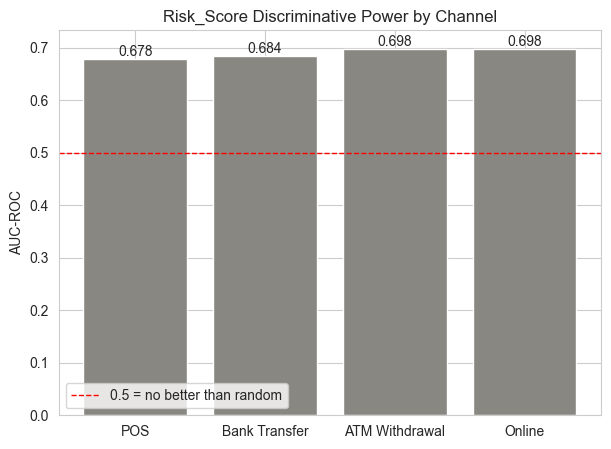

In [4]:
plt.figure(figsize=(7, 5))
bars = plt.bar(channel_summary.index, channel_summary["AUC-ROC"], color="#898781")
plt.bar_label(bars, fmt="%.3f")
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label="0.5 = no better than random")
plt.ylabel("AUC-ROC")
plt.title("Risk_Score Discriminative Power by Channel")
plt.legend()
plt.show()

**Finding:** `Risk_Score`'s discriminative power is weakest for **POS (AUC 0.678)**,
followed by Bank Transfer (0.684), while ATM Withdrawal and Online are both notably
stronger (0.698 each). This is a genuine model-quality gap, not just a threshold
artifact. This points toward
channel-specific model calibration or channel-aware features, not just a global
threshold adjustment.

## 3. Choosing an Operating Threshold by Expected Cost

Rather than a threshold that balances precision and recall equally (which implicitly
assumes a false positive and a false negative cost the business the same amount, rarely
true in fraud), I estimate the actual dollar cost of each threshold: every missed fraud
costs its transaction amount, and every false alarm costs an assumed investigation fee.

**I assume a $40 investigation cost per flagged transaction that turns out to be
legitimate.** This sits inside the commonly-cited $25–$50 per-alert range reported for
mid-size financial institutions ([FluxForce, 2024](https://www.fluxforce.ai/statistics/false-positive-rates-transaction-monitoring)), with a $25–$45 sweep in $10 increments analyzed in the appendix.

I then sweep thresholds and pick the one that minimizes total expected cost. **I apply
this one threshold uniformly across all four channels, rather than tuning a separate
cutoff per channel, for four reasons.** Each channel has roughly 1,900–2,000 fraud
cases — enough to support one global cost-minimization, but thin enough that splitting
it four ways risks fitting noise in each channel's cost curve rather than real signal.
`Risk_Score` itself is a single global score not built with channel-specific
calibration in mind, so a per-channel cutoff would be a downstream patch on an
un-recalibrated score rather than a genuine fix. Every additional threshold is an
additional parameter to monitor, audit, and explain — a real governance cost that
should be weighed against the benefit, not assumed away. And I have no evidence that
investigation cost meaningfully differs by channel, nor does missed-fraud severity
(already close across channels at around $100 per case).

In [5]:
investigation_cost_per_false_positive = 40

thresholds_to_test = np.arange(0.05, 0.96, 0.01)
cost_results = []

for threshold in thresholds_to_test:
    predicted_fraud = (df["Risk_Score"] >= threshold).astype(int)
    is_false_positive = (df["Fraud_Label"] == 0) & (predicted_fraud == 1)
    is_false_negative = (df["Fraud_Label"] == 1) & (predicted_fraud == 0)

    false_positive_cost = is_false_positive.sum() * investigation_cost_per_false_positive
    false_negative_cost = df.loc[is_false_negative, "Transaction_Amount"].sum()

    cost_results.append({
        "Threshold": round(threshold, 2),
        "False Positives": int(is_false_positive.sum()),
        "False Negatives": int(is_false_negative.sum()),
        "False Positive Cost": false_positive_cost,
        "False Negative Cost": round(false_negative_cost, 2),
        "Total Cost": round(false_positive_cost + false_negative_cost, 2),
    })

cost_curve = pd.DataFrame(cost_results)
best_row = cost_curve.loc[cost_curve["Total Cost"].idxmin()]
optimal_threshold = best_row["Threshold"]

print("Cost-minimizing threshold:", optimal_threshold)
print("Total expected cost at this threshold: $", best_row["Total Cost"])

Cost-minimizing threshold: 0.85
Total expected cost at this threshold: $ 575795.96


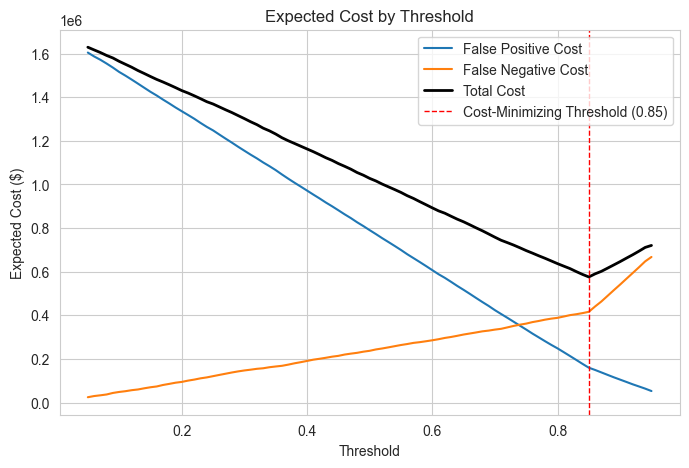

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(cost_curve["Threshold"], cost_curve["False Positive Cost"], label="False Positive Cost")
plt.plot(cost_curve["Threshold"], cost_curve["False Negative Cost"], label="False Negative Cost")
plt.plot(cost_curve["Threshold"], cost_curve["Total Cost"], label="Total Cost", linewidth=2, color="black")
plt.axvline(optimal_threshold, color="red", linestyle="--", linewidth=1,
            label=f"Cost-Minimizing Threshold ({optimal_threshold:.2f})")
plt.xlabel("Threshold")
plt.ylabel("Expected Cost ($)")
plt.title("Expected Cost by Threshold")
plt.legend()
plt.show()

In [7]:
df["Predicted_Fraud"] = (df["Risk_Score"] >= optimal_threshold).astype(int)
df["Missed_Fraud"] = (df["Fraud_Label"] == 1) & (df["Predicted_Fraud"] == 0)

precision = precision_score(df["Fraud_Label"], df["Predicted_Fraud"])
recall = recall_score(df["Fraud_Label"], df["Predicted_Fraud"])

date_range_days = (df["Timestamp"].max() - df["Timestamp"].min()).days
alerts_per_day = df["Predicted_Fraud"].sum() / date_range_days

print("At the cost-minimizing threshold:")
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("Approximate daily alert volume for a fraud ops team:", round(alerts_per_day, 1))

At the cost-minimizing threshold:
Precision: 0.474
Recall: 0.467
Approximate daily alert volume for a fraud ops team: 20.8


*A sensitivity check across a $25–$45 cost range (Appendix A) confirms this
threshold does not change anywhere in that range — the result is robust to the exact
cost assumption.*

## 4. Channel Priority at the Chosen Threshold

With an operating threshold set on business cost rather than statistical balance, I now
look at which channels carry the most missed-fraud exposure at that threshold — this is
the direct, actionable answer to "which channel should be the focus."

In [8]:
fraud_only = df[df["Fraud_Label"] == 1]

channel_detection = fraud_only.groupby("Channel").agg(
    Total_Fraud_Cases=("Fraud_Label", "size"),
    Fraud_Caught=("Predicted_Fraud", "sum"),
)
channel_detection["Detection Rate (%)"] = (
    channel_detection["Fraud_Caught"] / channel_detection["Total_Fraud_Cases"] * 100
).round(2)

missed_fraud_only = df[df["Missed_Fraud"]]
channel_exposure = missed_fraud_only.groupby("Channel")["Transaction_Amount"].sum().round(2)
channel_detection["Missed Fraud $ Exposure"] = channel_exposure

channel_detection = channel_detection.sort_values("Detection Rate (%)")
channel_detection

,Total_Fraud_Cases,Fraud_Caught,Detection Rate (%),Missed Fraud $ Exposure
Channel,,,,
Bank Transfer,1910,868,45.45,107117.26
POS,1896,874,46.10,105381.46
ATM Withdrawal,2001,946,47.28,103266.50
Online,1894,909,47.99,100124.47


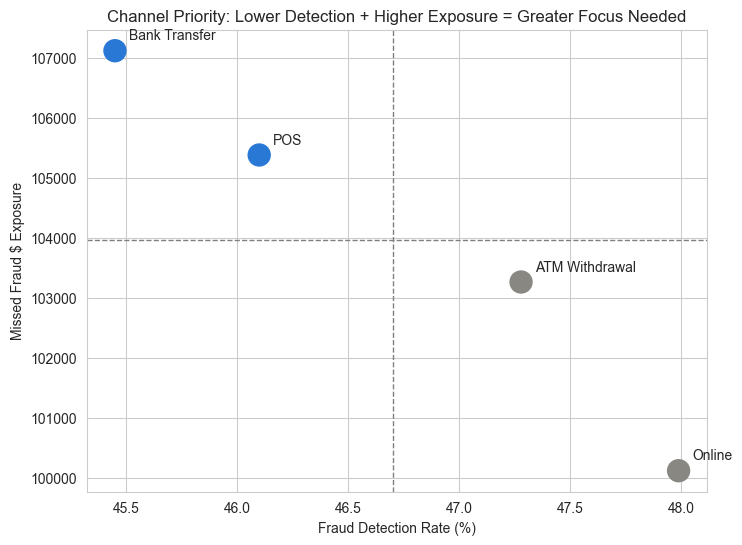

In [9]:
# A quadrant view of detection rate and missed fraud exposure
# carries the signal here, since detection rate and $ exposure both vary by only a
# few percent across channels. This also shows the relationship between the two
# metrics directly, rather than asking the reader to compare two separate panels.
plt.figure(figsize=(8, 6))

focus_channels = ["Bank Transfer", "POS"]
point_colors = ["#2a78d6" if channel in focus_channels else "#898781" for channel in channel_detection.index]

plt.scatter(
    channel_detection["Detection Rate (%)"],
    channel_detection["Missed Fraud $ Exposure"],
    color=point_colors,
    s=250,
    zorder=3,
)

for channel in channel_detection.index:
    plt.annotate(
        channel,
        (channel_detection.loc[channel, "Detection Rate (%)"], channel_detection.loc[channel, "Missed Fraud $ Exposure"]),
        textcoords="offset points", xytext=(10, 8),
    )

average_detection_rate = channel_detection["Detection Rate (%)"].mean()
average_exposure = channel_detection["Missed Fraud $ Exposure"].mean()

plt.axvline(average_detection_rate, color="gray", linestyle="--", linewidth=1)
plt.axhline(average_exposure, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Fraud Detection Rate (%)")
plt.ylabel("Missed Fraud $ Exposure")
plt.title("Channel Priority: Lower Detection + Higher Exposure = Greater Focus Needed")
plt.show()

## 5. Useful Features (Question 2)

Before considering any new engineered features, I first evaluate the features already
present in the dataset. `Risk_Score` is an existing model, so the immediate question is
which of the data already being captured is useful to a rule or model — not whether new
fields should be invented. Feature engineering, if still needed after this, belongs to
a later stage, once the value of what's already available has been established.

This section works in two steps: first each feature's contribution on its own (5.1),
then whether that contribution holds up once every feature is considered jointly,
accounting for redundancy between them (5.2).

### 5.1 Individual Feature Contribution (Weight of Evidence / Information Value)

I use Weight of Evidence (WOE) and Information Value (IV), the standard technique for
exactly this problem in credit and fraud risk scoring. Each feature is binned
(quantiles for numeric fields, native categories for categorical fields), and IV
measures how well those bins separate fraud from legitimate transactions — on one
comparable scale for both numeric and categorical features, which a plain correlation
coefficient cannot give for categorical fields. Standard interpretation bands: IV
< 0.02 = not predictive, 0.02–0.1 = weak, 0.1–0.3 = medium, 0.3–0.5 = strong, > 0.5 =
suspiciously strong (worth checking for leakage).

In [10]:
def calculate_woe_iv(data, feature, target):
    grouped = data.groupby(feature, observed=False)[target].agg(["count", "sum"])
    grouped.columns = ["Total", "Fraud_Count"]
    grouped["Non_Fraud_Count"] = grouped["Total"] - grouped["Fraud_Count"]

    total_fraud = grouped["Fraud_Count"].sum()
    total_non_fraud = grouped["Non_Fraud_Count"].sum()

    grouped["Pct_Fraud"] = grouped["Fraud_Count"] / total_fraud
    grouped["Pct_Non_Fraud"] = grouped["Non_Fraud_Count"] / total_non_fraud

    # a small epsilon avoids division by zero or log(0) for empty bins
    epsilon = 1e-6
    grouped["WOE"] = np.log((grouped["Pct_Non_Fraud"] + epsilon) / (grouped["Pct_Fraud"] + epsilon))
    grouped["IV_Contribution"] = (grouped["Pct_Non_Fraud"] - grouped["Pct_Fraud"]) * grouped["WOE"]

    return grouped["IV_Contribution"].sum()

In [11]:
numeric_features_to_test = [
    "Transaction_Amount", "Account_Balance", "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d", "Failed_Transaction_Count_7d",
    "Card_Tenure", "Transaction_Distance",
]
flag_features_to_test = ["IP_Address_Flag", "Previous_Fraudulent_Activity", "Is_Weekend"]
categorical_features_to_test = [
    "Channel", "Device_Type", "Merchant_Category", "Card_Type",
    "Authentication_Type", "Location",
]

iv_results = []

for feature in numeric_features_to_test:
    binned_data = df[[feature, "Fraud_Label"]].copy()
    binned_data[feature] = pd.qcut(binned_data[feature], q=5, duplicates="drop")
    iv_score = calculate_woe_iv(binned_data, feature, "Fraud_Label")
    iv_results.append({"Feature": feature, "Type": "Numeric", "Information Value": iv_score})

for feature in flag_features_to_test + categorical_features_to_test:
    feature_type = "Flag" if feature in flag_features_to_test else "Categorical"
    iv_score = calculate_woe_iv(df[[feature, "Fraud_Label"]], feature, "Fraud_Label")
    iv_results.append({"Feature": feature, "Type": feature_type, "Information Value": iv_score})


def classify_iv(iv_score):
    if iv_score < 0.02:
        return "Not predictive"
    elif iv_score < 0.1:
        return "Weak"
    elif iv_score < 0.3:
        return "Medium"
    elif iv_score < 0.5:
        return "Strong"
    else:
        return "Suspiciously strong"


iv_table = pd.DataFrame(iv_results)
iv_table["Predictive Power"] = iv_table["Information Value"].apply(classify_iv)
iv_table = iv_table.sort_values("Information Value", ascending=False).reset_index(drop=True)
iv_table

,Feature,Type,Information Value,Predictive Power
0,Failed_Transaction_Count_7d,Numeric,1.257256,Suspiciously strong
1,Location,Categorical,0.724045,Suspiciously strong
2,Avg_Transaction_Amount_7d,Numeric,0.001675,Not predictive
3,Device_Type,Categorical,0.001012,Not predictive
4,Channel,Categorical,0.000913,Not predictive
5,Authentication_Type,Categorical,0.000675,Not predictive
6,Daily_Transaction_Count,Numeric,0.000671,Not predictive
7,Previous_Fraudulent_Activity,Flag,0.000649,Not predictive
8,Card_Tenure,Numeric,0.000600,Not predictive
9,Transaction_Amount,Numeric,0.000541,Not predictive


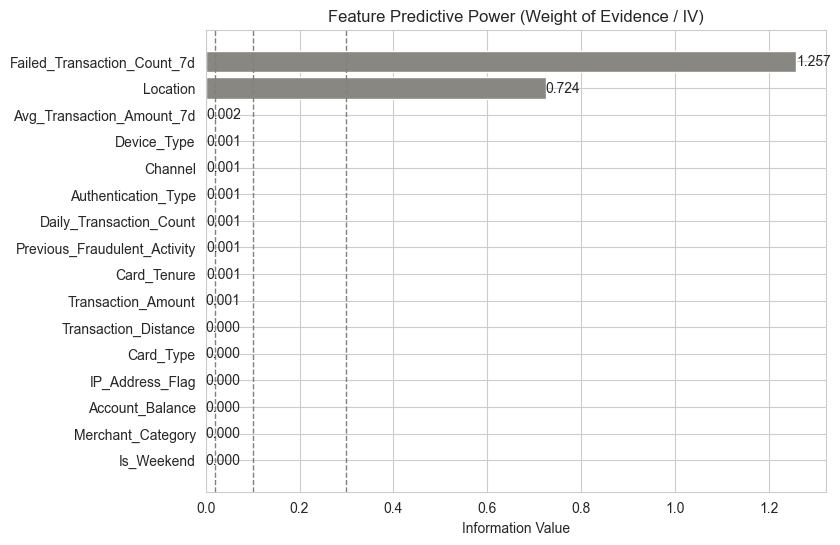

In [12]:
plt.figure(figsize=(8, 6))
bars = plt.barh(iv_table["Feature"], iv_table["Information Value"], color="#898781")
plt.bar_label(bars, fmt="%.3f")
plt.axvline(0.02, color="gray", linestyle="--", linewidth=1)
plt.axvline(0.1, color="gray", linestyle="--", linewidth=1)
plt.axvline(0.3, color="gray", linestyle="--", linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel("Information Value")
plt.title("Feature Predictive Power (Weight of Evidence / IV)")
plt.show()

**Finding:** two features stand far above the rest — `Failed_Transaction_Count_7d`
(IV = 1.26) and `Location` (IV = 0.72) — both flagged "suspiciously strong" under the
standard >0.5 threshold, which is exactly the right trigger to check for leakage
rather than a reason to discard them. On inspection, neither shows signs of leakage;
both are real, clean effects:
- `Failed_Transaction_Count_7d`'s fraud rate holds flat around 7% for 0–3 failed
  attempts, then jumps to 48.4% at exactly 4 — a near step-function threshold,
  consistent with a genuine card-testing/account-takeover signal, not a modeling
  artifact.
- `Location` was not examined anywhere earlier in this analysis, and turns out to be a
  genuinely powerful, previously undiscovered signal: fraud rate ranges from 1.6%
  (Sydney) and 2.2% (Beijing) up to 31.5% (Mumbai) and 31.7% (Paris) — roughly a 20x
  spread across seven cities. The split isn't a clean two-tier one, though — three
  cities (Toronto, New York, Tokyo) sit close to the overall base rate rather than
  low or high, a nuance Section 6 examines in more detail when turning this into a
  rule.

Every other existing field — `Transaction_Amount`, `Account_Balance`, `Channel`,
`Device_Type`, and the rest — scores below 0.002 ("not predictive") on IV alone.
Almost all of this dataset's predictive power concentrates in two fields, and one of
them was invisible to every prior section of this analysis until this univariate
check surfaced it.

### 5.2 Joint Feature Contribution (Logistic Regression Redundancy Check)

The IV ranking above treats every feature independently — it cannot see whether two
features are redundant with each other (so their combined value is less than the sum
of their individual IVs), or whether a feature that looks weak alone becomes useful
once paired with others. To check that, I fit a plain logistic regression — the
standard, interpretable baseline for exactly this purpose in credit and fraud
modeling — using the same existing features above (categorical fields one-hot
encoded), then use SHAP (SHapley Additive exPlanations) values to read off a
feature-importance view that accounts for these interactions. SHAP is the standard
way to attribute a model's prediction back to each input feature, and — unlike a raw
coefficient — it reflects each feature's actual contribution given the real
distribution of values in the data, not just its weight in isolation. As before, I
split by time (train on the earliest 80% of transactions, test on the most recent
20%) so the comparison against `Risk_Score` reflects genuine out-of-sample
performance.

In [13]:
categorical_dummies = pd.get_dummies(df[categorical_features_to_test], drop_first=True)

model_input = df[numeric_features_to_test + flag_features_to_test].join(categorical_dummies)
model_input["Timestamp"] = df["Timestamp"]
model_input["Fraud_Label"] = df["Fraud_Label"]
model_input["Risk_Score"] = df["Risk_Score"]

model_input_sorted = model_input.sort_values("Timestamp").reset_index(drop=True)
split_point = int(len(model_input_sorted) * 0.8)

train_data = model_input_sorted.iloc[:split_point]
test_data = model_input_sorted.iloc[split_point:]

feature_columns = numeric_features_to_test + flag_features_to_test + list(categorical_dummies.columns)

print("Number of features going into the model (including one-hot encoded categories):", len(feature_columns))
print("Train fraud rate:", round(train_data["Fraud_Label"].mean() * 100, 2), "%")
print("Test fraud rate:", round(test_data["Fraud_Label"].mean() * 100, 2), "%")

Number of features going into the model (including one-hot encoded categories): 31
Train fraud rate: 15.32 %
Test fraud rate: 15.74 %


In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_data[feature_columns])
X_test = scaler.transform(test_data[feature_columns])

y_train = train_data["Fraud_Label"]
y_test = test_data["Fraud_Label"]

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

predicted_probabilities = model.predict_proba(X_test)[:, 1]
model_auc = roc_auc_score(y_test, predicted_probabilities)
risk_score_auc_on_test = roc_auc_score(y_test, test_data["Risk_Score"])

print("Existing Risk_Score AUC (test period):", round(risk_score_auc_on_test, 4))
print("New model AUC (test period):        ", round(model_auc, 4))

Existing Risk_Score AUC (test period): 0.6818
New model AUC (test period):         0.8175


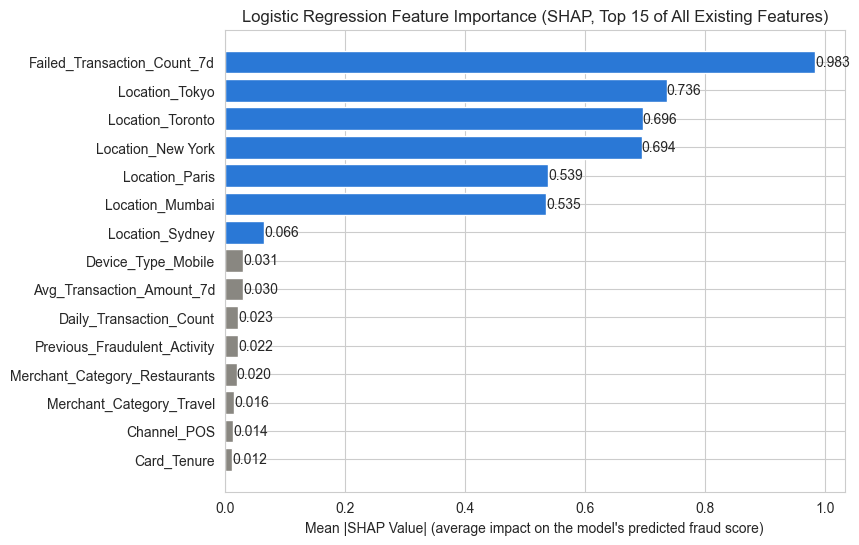

Combined SHAP importance of Failed_Transaction_Count_7d + all Location dummies: 4.249 out of 4.514 total across 31 features
Share of total feature importance: 94.1 %


In [15]:
masker = shap.maskers.Independent(X_train, max_samples=len(X_train))
explainer = shap.LinearExplainer(model, masker)
shap_values = explainer(X_test)

shap_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Mean |SHAP Value|": np.abs(shap_values.values).mean(axis=0),
})
shap_importance = shap_importance.sort_values("Mean |SHAP Value|", ascending=False).reset_index(drop=True)

top_features = shap_importance.head(15)
location_columns = [column for column in feature_columns if column.startswith("Location_")]
highlight_features = ["Failed_Transaction_Count_7d"] + location_columns
bar_colors = ["#2a78d6" if feature in highlight_features else "#898781" for feature in top_features["Feature"]]

plt.figure(figsize=(8, 6))
bars = plt.barh(top_features["Feature"], top_features["Mean |SHAP Value|"], color=bar_colors)
plt.bar_label(bars, fmt="%.3f")
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP Value| (average impact on the model's predicted fraud score)")
plt.title("Logistic Regression Feature Importance (SHAP, Top 15 of All Existing Features)")
plt.show()

total_shap_importance = shap_importance["Mean |SHAP Value|"].sum()
top_two_feature_importance = shap_importance[shap_importance["Feature"].isin(highlight_features)]["Mean |SHAP Value|"].sum()

print("Combined SHAP importance of Failed_Transaction_Count_7d + all Location dummies:",
      round(top_two_feature_importance, 3), "out of", round(total_shap_importance, 3), "total across 31 features")
print("Share of total feature importance:", round(top_two_feature_importance / total_shap_importance * 100, 1), "%")

In [16]:
restricted_feature_columns = ["Failed_Transaction_Count_7d"] + location_columns

restricted_scaler = StandardScaler()
restricted_X_train = restricted_scaler.fit_transform(train_data[restricted_feature_columns])
restricted_X_test = restricted_scaler.transform(test_data[restricted_feature_columns])

restricted_model = LogisticRegression(max_iter=1000, random_state=42)
restricted_model.fit(restricted_X_train, y_train)

restricted_model_auc = roc_auc_score(y_test, restricted_model.predict_proba(restricted_X_test)[:, 1])

print("AUC using only Failed_Transaction_Count_7d + Location:", round(restricted_model_auc, 4))
print("AUC using all 31 existing features:                   ", round(model_auc, 4))

AUC using only Failed_Transaction_Count_7d + Location: 0.8174
AUC using all 31 existing features:                    0.8175


**Finding:** the redundancy check confirms rather than overturns the IV ranking. SHAP
importance — which attributes the model's predicted fraud score back to each input
feature, accounting for the same interactions and correlations a joint model captures
— puts `Failed_Transaction_Count_7d` in first place by a clear margin (mean |SHAP| ≈
0.98), followed by the elevated-risk `Location` dummies (Tokyo, Toronto, New York,
Paris, Mumbai — 0.54–0.74 each), with `Location_Sydney` far behind, consistent with
Sydney's status as a low-fraud city. Together, `Failed_Transaction_Count_7d` and the
six `Location` dummies account for **94.1% of total SHAP importance across all 31
features** — nothing else comes close, echoing the individual-feature IV result from
5.1.

The practical result: a plain logistic regression built only from existing fields
reaches an **AUC-ROC of 0.818 on genuinely unseen future transactions, a 0.136-point
improvement over `Risk_Score`'s own 0.682 on the same period**. To test directly
whether that 0.818 can actually be attributed to just these two feature types — rather
than inferred from their SHAP dominance — I re-ran the same model restricted to only
`Failed_Transaction_Count_7d` and `Location`: it reached an AUC-ROC of **0.8174, within
0.0001 of the full 31-feature model's 0.8175**. Under AUC-ROC, these two existing
fields alone appear sufficient to deliver essentially all of this model's performance
uplift, with the other 29 features adding no measurable additional discrimination on
top of them. (Appendix C checks this same comparison under AUPRC — a metric more
sensitive to class imbalance — and finds a small but real residual gap that AUC-ROC
doesn't pick up, so "essentially all" is closer to "the large majority" once that's
accounted for.) This is a substantially larger uplift than an earlier iteration of
this analysis achieved using engineered ratio features (+0.073 AUC) — though that
comparison isn't perfectly apples-to-apples, since that attempt used a smaller,
numeric-only feature set. The larger gain here is attributable primarily to including
the categorical fields — especially `Location` — that earlier attempt left out
entirely.

## 6. Designing Rules from the Top Features

Sections 5.1 and 5.2 establish that `Failed_Transaction_Count_7d` and `Location` are
the two features worth acting on. Statistical strength alone doesn't make a feature
rule-ready, though — a good stand-alone rule needs a cut point that's sharp, stable,
and easy to explain to an investigator or auditor, not just a large IV or coefficient.
This section looks at the actual shape of each feature's relationship with fraud to
see whether a simple, transparent rule can be written directly from it, how well that
rule performs on its own, and what happens when the two are combined.

In [17]:
failed_txn_fraud_rate = df.groupby("Failed_Transaction_Count_7d")["Fraud_Label"].agg(["size", "mean"])
failed_txn_fraud_rate.columns = ["Transactions", "Fraud Rate (%)"]
failed_txn_fraud_rate["Fraud Rate (%)"] = (failed_txn_fraud_rate["Fraud Rate (%)"] * 100).round(2)
failed_txn_fraud_rate

,Transactions,Fraud Rate (%)
Failed_Transaction_Count_7d,,
0,10014,7.47
1,9919,7.25
2,9897,6.55
3,10216,7.52
4,9954,48.40


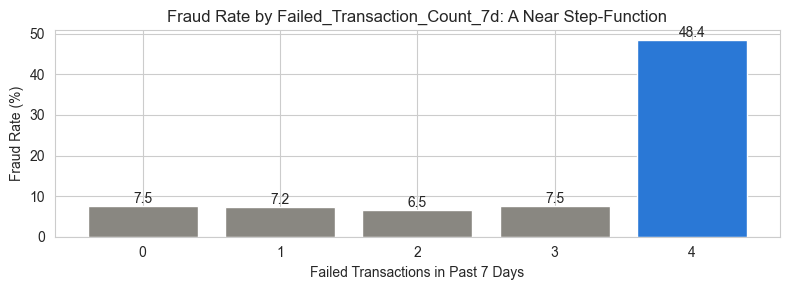

In [18]:
plt.figure(figsize=(8, 3))
bar_colors = ["#2a78d6" if count >= 4 else "#898781" for count in failed_txn_fraud_rate.index]
bars = plt.bar(failed_txn_fraud_rate.index.astype(str), failed_txn_fraud_rate["Fraud Rate (%)"], color=bar_colors)
plt.bar_label(bars, fmt="%.1f")
plt.xlabel("Failed Transactions in Past 7 Days")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Failed_Transaction_Count_7d: A Near Step-Function")
plt.tight_layout()
plt.show()

In [19]:
rule_failed_txn = (df["Failed_Transaction_Count_7d"] >= 4).astype(int)

print("Rule: flag if Failed_Transaction_Count_7d >= 4")
print("Precision:", round(precision_score(df["Fraud_Label"], rule_failed_txn), 3))
print("Recall:", round(recall_score(df["Fraud_Label"], rule_failed_txn), 3))
print("Coverage (% of all transactions flagged):", round(rule_failed_txn.mean() * 100, 2))

Rule: flag if Failed_Transaction_Count_7d >= 4
Precision: 0.484


Recall: 0.626
Coverage (% of all transactions flagged): 19.91


The break is sharp and near-binary: fraud rate holds flat at ~7% for 0–3 failed
attempts in the past week, then jumps to 48.4% at exactly 4 — consistent with a
card-testing or account-takeover pattern, where a burst of failed attempts signals an
attacker probing stolen credentials, rather than a genuine customer occasionally
mistyping a PIN. A single-field rule, **flag if `Failed_Transaction_Count_7d` >= 4**,
catches 62.6% of fraud while flagging only 19.9% of all transactions, at 48.4%
precision — a strong, fully transparent standalone rule with a natural, explainable
cutoff.

In [20]:
location_fraud_rate = df.groupby("Location")["Fraud_Label"].agg(["size", "mean"]).sort_values("mean")
location_fraud_rate.columns = ["Transactions", "Fraud Rate (%)"]
location_fraud_rate["Fraud Rate (%)"] = (location_fraud_rate["Fraud Rate (%)"] * 100).round(2)
location_fraud_rate

,Transactions,Fraud Rate (%)
Location,,
Sydney,5447,1.60
Beijing,5546,2.16
Toronto,9945,15.10
New York,9915,15.56
Tokyo,10208,15.91
Mumbai,4448,31.47
Paris,4491,31.73


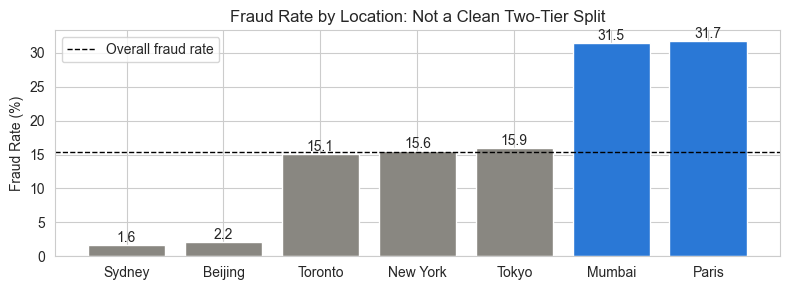

In [21]:
plt.figure(figsize=(8, 3))
high_risk_locations = ["Mumbai", "Paris"]
bar_colors = ["#2a78d6" if city in high_risk_locations else "#898781" for city in location_fraud_rate.index]
bars = plt.bar(location_fraud_rate.index, location_fraud_rate["Fraud Rate (%)"], color=bar_colors)
plt.bar_label(bars, fmt="%.1f")
plt.axhline(df["Fraud_Label"].mean() * 100, color="black", linestyle="--", linewidth=1, label="Overall fraud rate")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Location: Not a Clean Two-Tier Split")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
naive_location_rule = (~df["Location"].isin(["Sydney", "Beijing"])).astype(int)

print("Naive rule: flag if Location is not Sydney or Beijing")
print("Coverage (% of all transactions flagged):", round(naive_location_rule.mean() * 100, 2))
print("Precision:", round(precision_score(df["Fraud_Label"], naive_location_rule), 3))

Naive rule: flag if Location is not Sydney or Beijing
Coverage (% of all transactions flagged): 78.01
Precision: 0.192


Unlike `Failed_Transaction_Count_7d`, `Location` doesn't split cleanly into two tiers.
Sydney (1.6%) and Beijing (2.2%) are genuinely low-risk, and Mumbai (31.5%) and Paris
(31.7%) are genuinely elevated — but Toronto (15.1%), New York (15.6%), and Tokyo
(15.9%) sit almost exactly at the overall base rate (15.4%), so they carry no real
signal despite not being the lowest two cities. A rule built as "flag everything
except the two lowest cities" would look reasonable but performs badly in practice —
it flags 78% of all transactions at only 19.2% precision, since most of what it
catches is just the base rate rather than a genuinely elevated group. Isolating only
the two genuinely elevated cities into the rule instead gives a narrower but far more
honest signal.

In [23]:
rule_location = df["Location"].isin(high_risk_locations).astype(int)

print("Rule: flag if Location is Mumbai or Paris")
print("Precision:", round(precision_score(df["Fraud_Label"], rule_location), 3))
print("Recall:", round(recall_score(df["Fraud_Label"], rule_location), 3))
print("Coverage (% of all transactions flagged):", round(rule_location.mean() * 100, 2))

Rule: flag if Location is Mumbai or Paris
Precision: 0.316


Recall: 0.367
Coverage (% of all transactions flagged): 17.88


On its own, this location rule is a weaker standalone signal than the failed-transaction
rule (31.6% precision vs. 48.4%, 36.7% recall vs. 62.6%) — expected, since it only fires
on two of seven cities. Its value is in what it catches that the other rule misses, not
as a stand-alone flag, which is what the combination below tests.

In [24]:
rule_either = ((rule_failed_txn == 1) | (rule_location == 1)).astype(int)
rule_both = ((rule_failed_txn == 1) & (rule_location == 1)).astype(int)

non_fraud_count = (df["Fraud_Label"] == 0).sum()

rule_comparison = pd.DataFrame({
    "Rule": [
        "Failed_Transaction_Count_7d >= 4",
        "Location in {Mumbai, Paris}",
        "Either condition (OR)",
        "Both conditions (AND)",
    ],
    "Precision": [
        precision_score(df["Fraud_Label"], rule_failed_txn),
        precision_score(df["Fraud_Label"], rule_location),
        precision_score(df["Fraud_Label"], rule_either),
        precision_score(df["Fraud_Label"], rule_both),
    ],
    "Recall": [
        recall_score(df["Fraud_Label"], rule_failed_txn),
        recall_score(df["Fraud_Label"], rule_location),
        recall_score(df["Fraud_Label"], rule_either),
        recall_score(df["Fraud_Label"], rule_both),
    ],
    "FPR": [
        ((rule_failed_txn == 1) & (df["Fraud_Label"] == 0)).sum() / non_fraud_count,
        ((rule_location == 1) & (df["Fraud_Label"] == 0)).sum() / non_fraud_count,
        ((rule_either == 1) & (df["Fraud_Label"] == 0)).sum() / non_fraud_count,
        ((rule_both == 1) & (df["Fraud_Label"] == 0)).sum() / non_fraud_count,
    ],
    "Alerts/Day": [
        rule_failed_txn.sum() / date_range_days,
        rule_location.sum() / date_range_days,
        rule_either.sum() / date_range_days,
        rule_both.sum() / date_range_days,
    ],
})
rule_comparison[["Precision", "Recall", "FPR"]] = rule_comparison[["Precision", "Recall", "FPR"]].round(3)
rule_comparison["Alerts/Day"] = rule_comparison["Alerts/Day"].round(1)


def rule_cost_per_day(rule):
    false_positive_cost = ((rule == 1) & (df["Fraud_Label"] == 0)).sum() * investigation_cost_per_false_positive
    false_negative_cost = df.loc[(df["Fraud_Label"] == 1) & (rule == 0), "Transaction_Amount"].sum()
    return (false_positive_cost + false_negative_cost) / date_range_days


rule_comparison["Cost/Day"] = [
    rule_cost_per_day(rule_failed_txn),
    rule_cost_per_day(rule_location),
    rule_cost_per_day(rule_either),
    rule_cost_per_day(rule_both),
]
rule_comparison["Cost/Day"] = rule_comparison["Cost/Day"].round(2)
rule_comparison

,Rule,Precision,Recall,FPR,Alerts/Day,Cost/Day
0,Failed_Transaction_Count_7d >= 4,0.484,0.626,0.121,27.3,1374.87
1,"Location in {Mumbai, Paris}",0.316,0.367,0.145,24.5,2041.90
2,Either condition (OR),0.344,0.766,0.266,47.0,1742.94
3,Both conditions (AND),1.000,0.227,0.000,4.8,1673.83


**Finding:** the two features make rules with genuinely different shapes, and combining
them is a real business trade-off, not just a modeling detail. `Failed_Transaction_Count_7d`
alone is the stronger, cleaner rule (48.4% precision, 62.6% recall, ~27 alerts/day) thanks
to its sharp cutoff — already above the ~21 alerts/day the cost-optimal `Risk_Score`
threshold produces in Section 3. Requiring **both** conditions (AND) is the most extreme
trade-off: every transaction it flags turns out to be fraud in this data (100% precision),
but it only catches 22.7% of fraud, at just ~5 alerts/day — too narrow to serve as a
primary detection rule on its own, though it could work as a high-confidence auto-block
tier layered on top of a broader rule. Requiring **either** condition (OR) instead pushes
recall up to 76.6%, catching most fraud, but precision falls to 34.4% and alert volume
jumps to ~47/day — more than double the cost-optimal `Risk_Score` threshold's ~21/day, a
real increase in daily workload for a fraud ops team. None of these simple combinations
reach the full logistic regression's AUC of 0.818 (Section 5.2), because a hard-cutoff
rule can't weigh the two signals continuously against each other or draw on the smaller
effects of other features the way the model does. The practical choice is a matter of risk
appetite: the **AND** rule is a narrow, zero-false-positive tripwire; the **OR** rule casts
a wide, high-recall net at roughly double today's daily alert volume; `Failed_Transaction_Count_7d`
alone offers the strongest precision/recall combination of the three single-condition
options, making it the best single-field balance — even though its ~27 alerts/day isn't
the closest of the three to today's ~21/day (`Location` alone, at ~25/day, is nominally
closer but far weaker on both precision and recall). The full logistic regression remains
the stronger long-run answer once its governance and monitoring is in place.

### Benchmarking Against Today's System

The rule comparison above prices each rule in isolation. The number that actually
matters for a deployment decision is how each option compares to what the business is
already spending today. Section 3 already prices `Risk_Score` at its cost-minimizing
threshold using the same $40-per-false-alarm assumption; the same framework applies
directly to the winning rule (`Failed_Transaction_Count_7d >= 4`) and to the two-field
logistic regression from Section 5.2, so all three can be compared on one number: cost
per day. The model's own cost-minimizing threshold is found the same way as
`Risk_Score`'s (a sweep over the same $40 assumption), but necessarily evaluated on the
held-out test period only, since a model can only be judged honestly on data it never
trained on; `Risk_Score` and the rule are both evaluated on the full year, since
neither requires training data to begin with.

In [25]:
restricted_model_test_probabilities = restricted_model.predict_proba(restricted_X_test)[:, 1]

restricted_model_cost_results = []
for threshold in thresholds_to_test:
    predicted = (restricted_model_test_probabilities >= threshold).astype(int)
    is_false_positive = (test_data["Fraud_Label"] == 0) & (predicted == 1)
    is_false_negative = (test_data["Fraud_Label"] == 1) & (predicted == 0)

    false_positive_cost = is_false_positive.sum() * investigation_cost_per_false_positive
    false_negative_cost = test_data.loc[is_false_negative, "Transaction_Amount"].sum()

    restricted_model_cost_results.append({
        "Threshold": round(threshold, 2),
        "Total Cost": false_positive_cost + false_negative_cost,
    })

restricted_model_cost_curve = pd.DataFrame(restricted_model_cost_results)
restricted_model_best_row = restricted_model_cost_curve.loc[restricted_model_cost_curve["Total Cost"].idxmin()]
restricted_model_optimal_threshold = restricted_model_best_row["Threshold"]

restricted_model_predicted = (restricted_model_test_probabilities >= restricted_model_optimal_threshold).astype(int)
restricted_model_precision = precision_score(test_data["Fraud_Label"], restricted_model_predicted)
restricted_model_recall = recall_score(test_data["Fraud_Label"], restricted_model_predicted)

test_period_days = (test_data["Timestamp"].max() - test_data["Timestamp"].min()).days
restricted_model_alerts_per_day = restricted_model_predicted.sum() / test_period_days
restricted_model_cost_per_day = restricted_model_best_row["Total Cost"] / test_period_days

print("Two-field model cost-minimizing threshold (held-out test period):", restricted_model_optimal_threshold)
print("Precision:", round(restricted_model_precision, 3))
print("Recall:", round(restricted_model_recall, 3))
print("Alerts/day:", round(restricted_model_alerts_per_day, 1))
print("Cost/day: $", round(restricted_model_cost_per_day, 2))

Two-field model cost-minimizing threshold (held-out test period): 0.27
Precision: 0.523
Recall: 0.653
Alerts/day: 26.9
Cost/day: $ 1293.22


In [26]:
today_cost_per_day = best_row["Total Cost"] / date_range_days

baseline_comparison = pd.DataFrame({
    "Option": [
        "Today's System (Risk_Score @ 0.85)",
        "Rule: Failed_Transaction_Count_7d >= 4",
        "Two-Field Logistic Regression",
    ],
    "Precision": [
        round(precision, 3),
        round(precision_score(df["Fraud_Label"], rule_failed_txn), 3),
        round(restricted_model_precision, 3),
    ],
    "Recall": [
        round(recall, 3),
        round(recall_score(df["Fraud_Label"], rule_failed_txn), 3),
        round(restricted_model_recall, 3),
    ],
    "Alerts/Day": [
        round(alerts_per_day, 1),
        round(rule_failed_txn.sum() / date_range_days, 1),
        round(restricted_model_alerts_per_day, 1),
    ],
    "Cost/Day": [
        round(today_cost_per_day, 2),
        round(rule_cost_per_day(rule_failed_txn), 2),
        round(restricted_model_cost_per_day, 2),
    ],
})
baseline_comparison["Savings/Year vs. Today"] = (
    (today_cost_per_day - baseline_comparison["Cost/Day"]) * 365
).round(0)
baseline_comparison

,Option,Precision,Recall,Alerts/Day,Cost/Day,Savings/Year vs. Today
0,Today's System (Risk_Score @ 0.85),0.474,0.467,20.8,1577.52,1.0
1,Rule: Failed_Transaction_Count_7d >= 4,0.484,0.626,27.3,1374.87,73968.0
2,Two-Field Logistic Regression,0.523,0.653,26.9,1293.22,103771.0


**Finding:** both alternatives beat today's system on every dimension that matters —
more fraud caught, at lower cost. The `Failed_Transaction_Count_7d >= 4` rule is
estimated to save roughly **$74K/year** versus today's threshold (62.6% recall vs.
46.7%, at a lower daily cost), and is deployable immediately with no model-governance
cycle. The two-field logistic regression goes further — an estimated **$104K/year** in
savings, 65.3% recall, and the best precision of any option tested (52.3%) — but
requires the validation and monitoring a live model needs before it can be deployed.
This is the direct dollar case for the phased rollout recommended below: ship the rule
now, fast-track the model behind it.

## 7. Recommendations Summary

**Question 1 — Which channel should be the focus?**
Two independent lenses agree: **POS and Bank Transfer**. `Risk_Score` has genuinely
weaker discriminative power on POS (AUC 0.678, the lowest of any channel) — a
model-quality gap, not a threshold problem. At the cost-minimized operating threshold,
**Bank Transfer has the lowest detection rate (45.5%) and the highest missed-fraud
dollar exposure ($107,117)**, with POS a close second (46.1% detection, $105,381
exposure). Both channels deserve dedicated review; POS specifically needs the
underlying score re-examined, not just re-tuned.

**Question 2 — What features are useful for a rule/model, and why?**
- `Failed_Transaction_Count_7d` is the standout signal, both alone (IV 1.26, the
  highest of any feature) and jointly with everything else (SHAP importance ≈ 0.98,
  the single largest of any feature). Its effect is a near step-function: flat ~7%
  fraud rate for 0–3 failed attempts, then 48.4% at 4 — a clean, explainable,
  rule-friendly threshold.
- `Location` is the standout discovery of this feature-selection exercise: it scores
  nearly as strongly on its own (IV 0.72) and holds up fully once modeled jointly
  (five elevated-risk cities all carrying large, consistent SHAP importance vs. the
  two lowest-risk cities, Sydney and Beijing). It was not examined in any earlier
  section of this analysis. `Risk_Score`'s own inputs and methodology aren't visible
  in this dataset, so I can't say whether it already accounts for location in some
  form — only that a model built with it, using fields already in the data, clearly
  outperforms `Risk_Score` on the same held-out period.
- Every other existing field — `Transaction_Amount`, `Account_Balance`, `Channel`,
  `Device_Type`, `Merchant_Category`, `Card_Type`, `Authentication_Type`,
  `IP_Address_Flag`, `Previous_Fraudulent_Activity`, `Card_Tenure`,
  `Transaction_Distance`, `Daily_Transaction_Count`, `Avg_Transaction_Amount_7d`, and
  `Is_Weekend` — scores as not predictive, individually and jointly. None should be
  prioritized as standalone rule inputs.
- A plain logistic regression using only these existing fields reaches an AUC-ROC of
  0.818 on held-out future data, a 0.136-point improvement over `Risk_Score`'s own
  0.682 on the same period. A model restricted to only `Failed_Transaction_Count_7d`
  and `Location` reaches an almost identical 0.8174 under AUC-ROC — strong evidence
  these two fields alone account for the large majority of that uplift (a
  precision-recall-based check in Appendix C finds a small residual gap AUC-ROC
  doesn't capture, so a handful of the other fields likely contribute a modest amount
  too). Either way, the immediate opportunity is using data already being captured
  more effectively, not collecting new data, regardless of what `Risk_Score`
  currently does or doesn't use internally.

**Recommendation:** first confirm what `Risk_Score` actually uses today — its inputs
and methodology aren't visible in this dataset, so before rebuilding anything it's
worth checking whether `Failed_Transaction_Count_7d` and `Location` are already
inputs it underweights, or are missing from it entirely. Either way, the evidence
here says a model built around these two fields is worth deploying: a plain logistic
regression on existing fields alone already closes most of the gap to a usable model
(AUC 0.818 vs. 0.682). Priced out in Section 6, this isn't just a statistical
improvement: the `Failed_Transaction_Count_7d >= 4` rule is an estimated **$74K/year**
cheaper to run than today's threshold, and the two-field model an estimated
**$104K/year** cheaper, while both catch materially more fraud. The practical path is
phased — ship the rule this week as a zero-risk stopgap, then fast-track the model
behind it, since it beats the rule on precision, recall, and cost alike. Separately,
prioritize a channel-specific recalibration for POS given its uniquely weak AUC, and
keep setting the operating threshold using expected-cost minimization (0.85 here)
rather than a purely statistical balance.

## Appendix A. Sensitivity to the Investigation Cost Assumption

Since $40 is a cited assumption rather than an audited figure (Section 3), I re-run
the same cost-minimization across a $25–$45 sweep in $10 increments — within the
commonly-cited $25–$50 per-alert range — to check whether the recommended threshold —
and the resulting precision/recall trade-off — actually depends on getting this
number exactly right.

In [27]:
def find_cost_minimizing_threshold(investigation_cost):
    cost_results = []
    for threshold in thresholds_to_test:
        predicted_fraud = (df["Risk_Score"] >= threshold).astype(int)
        is_false_positive = (df["Fraud_Label"] == 0) & (predicted_fraud == 1)
        is_false_negative = (df["Fraud_Label"] == 1) & (predicted_fraud == 0)

        false_positive_cost = is_false_positive.sum() * investigation_cost
        false_negative_cost = df.loc[is_false_negative, "Transaction_Amount"].sum()
        total_cost = false_positive_cost + false_negative_cost

        cost_results.append({"Threshold": round(threshold, 2), "Total Cost": total_cost})

    results = pd.DataFrame(cost_results)
    best = results.loc[results["Total Cost"].idxmin()]
    return best["Threshold"]


cost_assumptions_to_test = [25, 35, 45]
sensitivity_results = []

for cost_assumption in cost_assumptions_to_test:
    best_threshold = find_cost_minimizing_threshold(cost_assumption)
    predicted_fraud_at_threshold = (df["Risk_Score"] >= best_threshold).astype(int)

    sensitivity_results.append({
        "Assumed Investigation Cost": f"${cost_assumption}",
        "Cost-Minimizing Threshold": best_threshold,
        "Precision": round(precision_score(df["Fraud_Label"], predicted_fraud_at_threshold), 3),
        "Recall": round(recall_score(df["Fraud_Label"], predicted_fraud_at_threshold), 3),
    })

sensitivity_table = pd.DataFrame(sensitivity_results)
sensitivity_table

,Assumed Investigation Cost,Cost-Minimizing Threshold,Precision,Recall
0,$25,0.85,0.474,0.467
1,$35,0.85,0.474,0.467
2,$45,0.85,0.474,0.467


**Finding:** the cost-minimizing threshold is **completely stable across the entire
$25–$45 range** — it stays at exactly 0.85 (47.4% precision, 46.7% recall, around 21 alerts
per day) whether the true investigation cost is $25, $35, or $45. That means the exact
dollar figure within this commonly-cited per-alert range doesn't actually change the
recommendation — the $40 assumption could be off by ±$15 and the operating threshold,
and everything downstream of it, would be unaffected. This is a reassuring robustness
result: the analysis doesn't depend on getting an unaudited cost figure exactly right,
only on it falling somewhere in the range the industry sources support.

## Appendix B. Stability Check via Time-Series Cross-Validation

The 0.818 AUC from Section 5.2 comes from a single train/test split, so it's one draw
from one particular chronological cut of the year. To check whether that number is
stable rather than a property of this specific split, I re-fit the same model using
3-fold time-series cross-validation *within the training window only* — each fold
trains on an earlier chunk and tests on the chunk right after it, so there is still no
lookahead leakage. This never touches the true final test period; the 0.818 figure
from Section 5.2 remains the primary, uncontaminated comparison against `Risk_Score`.
This is purely a check on whether that number can be trusted, not a replacement for
it. Note also that cross-validation here only evaluates the *approach* — the model
actually recommended for deployment would still be trained on all available history,
not on whatever smaller slice a given fold happens to see.

In [28]:
time_series_splits = TimeSeriesSplit(n_splits=3)
cv_auc_scores = []

for fold_train_index, fold_test_index in time_series_splits.split(train_data):
    fold_train = train_data.iloc[fold_train_index]
    fold_test = train_data.iloc[fold_test_index]

    fold_scaler = StandardScaler()
    fold_X_train = fold_scaler.fit_transform(fold_train[feature_columns])
    fold_X_test = fold_scaler.transform(fold_test[feature_columns])

    fold_model = LogisticRegression(max_iter=1000, random_state=42)
    fold_model.fit(fold_X_train, fold_train["Fraud_Label"])

    fold_predictions = fold_model.predict_proba(fold_X_test)[:, 1]
    fold_auc = roc_auc_score(fold_test["Fraud_Label"], fold_predictions)
    cv_auc_scores.append(fold_auc)

    print("Fold train size:", len(fold_train), "| Fold test size:", len(fold_test),
          "| Fold AUC:", round(fold_auc, 4))

print()
print("Mean CV AUC:", round(np.mean(cv_auc_scores), 4), "| Std across folds:", round(np.std(cv_auc_scores), 4))

Fold train size: 10000 | Fold test size: 10000 | Fold AUC: 0.8134
Fold train size: 20000 | Fold test size: 10000 | Fold AUC: 0.8124
Fold train size: 30000 | Fold test size: 10000 | Fold AUC: 0.8095

Mean CV AUC: 0.8118 | Std across folds: 0.0016


**Finding:** the 0.818 AUC holds up. Across the three folds — even the thinnest,
trained on only 10,000 rows (~1,540 fraud cases) versus the primary split's 40,000 —
AUC ranges from 0.810 to 0.813, a **mean of 0.812 with a standard deviation of just
0.002**. That the smallest fold performs essentially the same as the largest is
itself informative: it confirms the earlier concern about thinner folds adding
noise didn't materialize here, most likely because the two dominant signals
(`Failed_Transaction_Count_7d` and `Location`) are strong and clean enough that even
a few thousand fraud cases are enough to estimate them reliably. The close match
between this cross-validated mean (0.812) and the final holdout AUC (0.818) is
reassuring: the headline uplift over `Risk_Score` is not an artifact of one
favorable split.

## Appendix C. AUPRC Robustness Check

AUC-ROC was chosen as the primary metric throughout this analysis (Sections 2, 5.2,
and Appendix B) because it has an intuitive, easy-to-explain baseline: **0.5 means a
score is no better than randomly guessing** whether a transaction is fraud, and
anything above that reflects genuine ability to separate real fraud from legitimate
transactions. That framing maps directly onto the case study's central question — how
well does `Risk_Score` actually distinguish fraud from non-fraud — in a way a
non-technical audience can follow without needing to understand precision or recall
first.

That said, every AUC figure in this analysis is specifically **AUC-ROC** (area under
the ROC curve), and with a 15.4% fraud rate this dataset has a genuine, if moderate,
class imbalance — not severe enough to make AUC-ROC misleading on its own, but
imbalanced enough that AUC-ROC's false-positive-rate axis can look more favorable than
a metric that weighs the minority (fraud) class more directly. **AUPRC (Average
Precision, the area under the precision-recall curve)** is the standard alternative
under imbalance, since it doesn't dilute performance against the large majority class
the way AUC-ROC's axis can. I re-ran the three key comparisons from Section 5.2 —
`Risk_Score`, the full 31-feature model, and the 2-feature restricted model — under
AUPRC, to check whether the headline conclusions still hold under a metric more
sensitive to this kind of imbalance.

In [29]:
restricted_predicted_probabilities = restricted_model.predict_proba(restricted_X_test)[:, 1]

no_skill_baseline = y_test.mean()

auprc_comparison = pd.DataFrame({
    "Model": ["Risk_Score", "Full model (31 features)", "Restricted model (2 fields)"],
    "AUC-ROC": [
        roc_auc_score(y_test, test_data["Risk_Score"]),
        model_auc,
        restricted_model_auc,
    ],
    "AUPRC": [
        average_precision_score(y_test, test_data["Risk_Score"]),
        average_precision_score(y_test, predicted_probabilities),
        average_precision_score(y_test, restricted_predicted_probabilities),
    ],
})
auprc_comparison[["AUC-ROC", "AUPRC"]] = auprc_comparison[["AUC-ROC", "AUPRC"]].round(4)

print("No-skill AUPRC baseline (test period fraud rate):", round(no_skill_baseline, 4))
auprc_comparison

No-skill AUPRC baseline (test period fraud rate): 0.1574


,Model,AUC-ROC,AUPRC
0,Risk_Score,0.6818,0.3413
1,Full model (31 features),0.8175,0.5683
2,Restricted model (2 fields),0.8174,0.5576


**Finding:** the headline conclusions hold — and if anything strengthen — under AUPRC.
`Risk_Score`'s AUPRC (0.341) sits at roughly 2.2x the no-skill baseline (0.157, the test
period's fraud rate), while the full model's AUPRC (0.568) sits at roughly 3.6x
baseline — an even clearer separation than the two show under AUC-ROC (0.682 vs.
0.818), since AUPRC is more sensitive to how well a classifier ranks the rarer fraud
cases specifically, which AUC-ROC's false-positive-rate axis can understate under
moderate imbalance.

One nuance AUC-ROC missed: under AUPRC, the 2-field restricted model (0.558) trails the
full 31-feature model (0.568) by a small but real margin, where AUC-ROC showed them as
essentially identical (0.8174 vs. 0.8175). This doesn't overturn the Section 5.2
conclusion that `Failed_Transaction_Count_7d` and `Location` carry the large majority
of the signal — they still account for 94.1% of SHAP importance and drive nearly all of
the AUC-ROC uplift — but it's a more honest picture than "essentially all": the other 29
features do contribute a modest, real amount of precision-recall performance that
AUC-ROC's less-imbalance-sensitive scale didn't surface. For a deployment decision this
doesn't change the recommendation (the two-field rule in Section 6 and the two-field
model both remain the right near-term move), but it's worth knowing before over-stating
how completely these two fields explain the full model's performance.